Sean Bergan

Referring to `Python_exploring_h5ad_files.ipynb` and the [Scanpy Preprocessing and clustering tutorial](https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html#nearest-neighbor-graph-construction-and-visualization).

**This notebook includes:**
- Reading in h5ad files in our dataset
- Figuring out variable names in our adata and seeing if using ad.concat() + adding a `sample` column, vs. using sc.concat(), affects things downstream
- Exploring adata
- Examining the cell labels in the cell metadata (adata.obs['AIFI_L2']) to see if any labels are underrepresented in any of the drug treatments
     - Visualizing with bar charts and heatmaps
-  Scanpy preprocessing, dimensionality reduction (PCA, UMAPs) and clustering

In [1]:
# Core libraries
import hisepy
import numpy as np
import scanpy as sc
import anndata as ad
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/leidenalg/VertexPartition.py:413: SyntaxWarning: invalid escape sequence '\m'
  .. math:: Q = \\frac{1}{m} \\sum_{ij} \\left(A_{ij} - \\frac{k_i^\mathrm{out} k_j^\mathrm{in}}{m} \\right)\\delta(\\sigma_i, \\sigma_j),
/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/leidenalg/VertexPartition.py:788: SyntaxWarning: invalid escape sequence '\m'
  .. math:: Q = \\sum_{ij} \\left(A_{ij} - \\gamma \\frac{k_i^\mathrm{out} k_j^\mathrm{in}}{m} \\right)\\delta(\\sigma_i, \\sigma_j),
/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/leidenalg/Optimiser.py:27: SyntaxWarning: invalid escape sequence '\g'
  implementation therefore does not guarantee subpartition :math:`\gamma`-density.
/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/leidenalg/Optimiser.py:346: SyntaxWarning: invalid escape sequence '\s'
  .. math:: Q = \sum_k \\lambda_k Q_k.


# Read in .h5ad files in our File Set

In [2]:
h5ad_files = hisepy.cache_fileset('f48bf688-1a5f-456c-b0b0-c6ec870ec003')

In [3]:
# view the first five file names
h5ad_files[0:5]

['/home/workspace/input/1742749117/fileset/f48bf688-1a5f-456c-b0b0-c6ec870ec003/rhodium-niobium-silver/Afatinib_BIBW2992_counts_filtered_labeled_sampled.h5ad',
 '/home/workspace/input/1742749117/fileset/f48bf688-1a5f-456c-b0b0-c6ec870ec003/rhodium-niobium-silver/Afatinib_dimaleate_counts_filtered_labeled_sampled.h5ad',
 '/home/workspace/input/1742749117/fileset/f48bf688-1a5f-456c-b0b0-c6ec870ec003/rhodium-niobium-silver/Baricitinib_LY3009104_INCB028050_counts_filtered_labeled_sampled.h5ad',
 '/home/workspace/input/1742749117/fileset/f48bf688-1a5f-456c-b0b0-c6ec870ec003/rhodium-niobium-silver/Baricitinib_phosphate_counts_filtered_labeled_sampled.h5ad',
 '/home/workspace/input/1742749117/fileset/f48bf688-1a5f-456c-b0b0-c6ec870ec003/rhodium-niobium-silver/Canertinib_CI-1033_counts_filtered_labeled_sampled.h5ad']

In [4]:
# initialize a list
adata_list = []

# iterate over the list h5ad_files to use Scanpy to read the file
for h5ad_file in h5ad_files:
    adata = sc.read_h5ad(h5ad_file)
    # append anndata file object into the list
    adata_list.append(adata)

In [5]:
# view the first item of the list
adata_list[0]

AnnData object with n_obs × n_vars = 25000 × 1916
    obs: 'original_barcodes', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_umis', 'n_genes', 'plate_location', 'cyto_treatment', 'drug_treatment', 'drug_name', 'drug_cas_number', 'drug_mw', 'drug_solvent', 'drug_pathway', 'drug_target', 'drug_description', 'drug_chembl_name', 'drug_chembl_id', 'AIFI_L1', 'AIFI_L2', 'leiden_2'
    uns: 'drug_name_colors', 'leiden_2', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'

In [6]:
# using anndata to concatenate: code chunk from Scanpy tutorial

# combine multiple anndata objects and adds a "sample" column telling you which dataset each cell came from; aka, which DRUG NAME each cell was treated with!
adata = ad.concat(adata_list, label="sample")

# make sure all observations are unique
adata.obs_names_make_unique()

# filtering out CD8aa because there aren't enough
adata = adata[adata.obs.AIFI_L2 != "CD8aa"]

/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/anndata/_core/merge.py:1667: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  concat_annot = pd.concat(


## Cleaning up labels
Removing accession numbers/ids from the drug names for the sake of presentation figures

In [7]:
import re

unique_drug_names = adata.obs['drug_name'].unique()

def clean_name(name):
    name = re.sub(' \\(.*\\) ', ' ', name)
    name = re.sub(' \\(.*\\)$', '', name)
    return name

# for name in unique_drug_names:
#     print(clean_name(name))

adata.obs['clean_drug_name'] = adata.obs['drug_name'].copy().apply(clean_name)

# .map(clean_mapping)

/tmp/ipykernel_1866/15385615.py:13: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['clean_drug_name'] = adata.obs['drug_name'].copy().apply(clean_name)


## Normalization

In [8]:
# help(adata)
adata.layers["counts"] = adata.X.copy()

# Normalizing to median total counts
sc.pp.normalize_total(adata, target_sum = 1e4)


adata.layers["log_transformed"] = np.log1p(adata.X)
# Logarithmize the data
sc.pp.log1p(adata)
# sc.pp.scale(adata)

## Trying out DEG
Seems we may need to filter our genes first (didn't fix it)

was getting log2 scanpy/numpy errors... those went away after commenting out scale() earlier, but now we have divide by zero errors when using the wilcoxon method.

In [9]:
# making a dictionary of subsetted data where the key is the cell type and the value is the anndata object
subsets_cells = {}

for cell_type in adata.obs['AIFI_L2'].unique():
    # print(f'current cell type is {cell_type}')
    cell_type_subset = adata[adata.obs.AIFI_L2 == cell_type].copy()
    sc.tl.rank_genes_groups(
        adata = cell_type_subset,
        groupby = "clean_drug_name",
        reference = "DMSO Control",
        method = "wilcoxon",
        layer = "log_transformed"
    )
    subsets_cells[cell_type] = cell_type_subset

# print(subsets_cells)

# figure out grabbing the data frames from these -- adata.to_df()

# get_rank

In [10]:
# for cell_type, subset_cell in subsets_cells.items():    
#     print(cell_type)
#     sc.pl.rank_genes_groups_dotplot(subset_cell, groupby="drug_name", n_genes=5)

Trying to make sense of the above dot plots, it at first seemed like the columns are repeating information since the reference is only ever the DMSO control. It seems like this is actually picking out the top 5 differentially expressed genes against the reference for each treatment, and is *then* showing the levels those genes are expressed across **all** of the treatments.

## Counts for up/down regulation

In [57]:
# todo: add distinction for gene regulation in common with IL6

# tracking all gene names that are up/down regulated in any cell
up_across_cells = set()
down_across_cells = set()

# add in grouping by drug
# plot as bar plot or heat map


def graph_diff_gene_counts_with_agreement(lfc_threshold):
    # initialize the dataframe
    all_cells_sig_genes = pd.DataFrame({'cell_type':[], 'names': [], 'regulation_dir': []})
    
    for cell_type, subset_cell in subsets_cells.items():
        print("================================")
        print(cell_type)
        print("================================")
        cell_df = sc.get.rank_genes_groups_df(subset_cell, group=None)
    
        # make a column that is absolute value of logfold change
        cell_df['abs_logfoldchanges'] = cell_df['logfoldchanges'].abs()
    
        # filter for absolute value of log fold change > 1 and adjusted p values less than 0.05
        sig_diff = cell_df[(cell_df['pvals_adj'] < 0.05) & (cell_df['abs_logfoldchanges'] > lfc_threshold)].sort_values(by = 'abs_logfoldchanges', ascending = False)
    
        # add a categorical variable showing up or down regulation
        sig_diff['regulation_dir'] = np.where(sig_diff['logfoldchanges'] > 0, 'Up', 'Down')
        sig_diff['cell_type'] = cell_type
        print(sig_diff.head())

        # get sets of each of the genes up/down in IL6 to plot agreement counts within the graph
        up_in_il6 = set(sig_diff[[''] == 'IL6 Control', regulation_counts == 'Up']['names'])
        down_in_il6 = sig_diff[['names'] == 'IL6 Control', regulation_counts == 'Down']
    
        
        counts_by_treatment = sig_diff.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')
        plt.figure(figsize = (12, 5))
        #x-axis is cell type labels AIFI_L2, y-axis is count, hue (grouping by) drug_name
        sns.barplot(data = counts_by_treatment, x = "group", y = "count", hue = "regulation_dir")
        plt.xticks(rotation = 45, ha = 'right')
        plt.title(cell_type)
        plt.xlabel("Treatment")
        plt.ylabel("Count")
        
        #moving the legend to be outside of the plot
        plt.legend(title="Regulation direction")
        plt.tight_layout()
        file_name = f'figures/reg_counts_{cell_type}_threshold_{lfc_threshold}'.replace('.', '_').replace(' ', '_') + '.svg'
        plt.savefig(file_name)
        plt.show()
    
        # print(sig_diff.groupby('regulation')['regulation'].count())
        # concatenating these to our data frame across all cell types with a label for what the cell type is
        # also making it unique so we don't have duplicate counts across different treatment types
        all_cells_sig_genes = pd.concat([all_cells_sig_genes, sig_diff[['cell_type', 'names', 'regulation_dir']]]).drop_duplicates()
    
    print("================================")
    print("All cells")
    print("================================")
    regulation_counts = all_cells_sig_genes.groupby(['cell_type', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')
    print(regulation_counts)
    
    #todo: reorder the treatments
    
    # bar plot:
    print(all_cells_sig_genes[['names', 'regulation_dir']].drop_duplicates().groupby('regulation_dir').count())
    
    plt.figure(figsize = (12, 5))
    #x-axis is cell type labels AIFI_L2, y-axis is count, hue (grouping by) drug_name
    sns.barplot(data = regulation_counts, x = "cell_type", y = "count", hue = "regulation_dir")
    plt.xticks(rotation = 90)
    plt.xlabel("Cell type label (AIFI_L2)")
    plt.ylabel("Count")
    
    #moving the legend to be outside of the plot

    plt.legend(title="Regulation direction")
    plt.tight_layout()
    plt.show()


In [33]:
# todo: add distinction for gene regulation in common with IL6
# todo: adjust the threshold to 0.1 as well

# tracking all gene names that are up/down regulated in any cell
up_across_cells = set()
down_across_cells = set()

# add in grouping by drug
# plot as bar plot or heat map


def graph_diff_gene_counts(lfc_threshold):
    # initialize the dataframe
    all_cells_sig_genes = pd.DataFrame({'cell_type':[], 'names': [], 'regulation_dir': []})
    
    for cell_type, subset_cell in subsets_cells.items():
        print("================================")
        print(cell_type)
        print("================================")
        cell_df = sc.get.rank_genes_groups_df(subset_cell, group=None)
    
        # make a column that is absolute value of logfold change
        cell_df['abs_logfoldchanges'] = cell_df['logfoldchanges'].abs()
    
        # filter for absolute value of log fold change > 1 and adjusted p values less than 0.05
        sig_diff = cell_df[(cell_df['pvals_adj'] < 0.05) & (cell_df['abs_logfoldchanges'] > lfc_threshold)].sort_values(by = 'abs_logfoldchanges', ascending = False)
    
        # add a categorical variable showing up or down regulation
        sig_diff['regulation_dir'] = np.where(sig_diff['logfoldchanges'] > 0, 'Up', 'Down')
        sig_diff['cell_type'] = cell_type
        # print(sig_diff.head())
    
        
        counts_by_treatment = sig_diff.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')
        plt.figure(figsize = (12, 6))
        #x-axis is cell type labels AIFI_L2, y-axis is count, hue (grouping by) drug_name
        sns.barplot(data = counts_by_treatment, x = "group", y = "count", hue = "regulation_dir")
        plt.xticks(rotation = 90)
        plt.title(cell_type)
        plt.xlabel("Treatment")
        plt.ylabel("Count")
        
        #moving the legend to be outside of the plot
        plt.legend(title="Regulation direction", bbox_to_anchor=(1.05, 1))
        plt.tight_layout()
        file_name = f'{cell_type}_threshold_{lfc_threshold}'.replace('.', '_').replace(' ', '_') + '.svg'
        plt.savefig(file_name)
        plt.show()
    
        # print(sig_diff.groupby('regulation')['regulation'].count())
        # concatenating these to our data frame across all cell types with a label for what the cell type is
        # also making it unique so we don't have duplicate counts across different treatment types
        all_cells_sig_genes = pd.concat([all_cells_sig_genes, sig_diff[['cell_type', 'names', 'regulation_dir']]]).drop_duplicates()
    
    print("================================")
    print("All cells")
    print("================================")
    regulation_counts = all_cells_sig_genes.groupby(['cell_type', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')
    print(regulation_counts)
    
    #todo: reorder the treatments
    
    # bar plot:
    print(all_cells_sig_genes[['names', 'regulation_dir']].drop_duplicates().groupby('regulation_dir').count())
    
    plt.figure(figsize = (12, 6))
    #x-axis is cell type labels AIFI_L2, y-axis is count, hue (grouping by) drug_name
    sns.barplot(data = regulation_counts, x = "cell_type", y = "count", hue = "regulation_dir")
    plt.xticks(rotation = 90)
    plt.xlabel("Cell type label (AIFI_L2)")
    plt.ylabel("Count")
    
    #moving the legend to be outside of the plot
    plt.legend(title="Regulation direction", bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()


In [58]:
graph_diff_gene_counts_with_agreement(lfc_threshold = 0.1)

CD4 Central Memory
                           group  names     scores  logfoldchanges  \
7664                  Canertinib  HMGB2  55.764740        2.965033   
9580  Canertinib dihydrochloride  HMGB2  55.677532        2.919789   
7818                  Canertinib   IGHM   4.459087        2.811832   
9738  Canertinib dihydrochloride   IGHM   4.203644        2.714745   
7668                  Canertinib   BATF  32.710278        2.355659   

              pvals      pvals_adj  abs_logfoldchanges regulation_dir  \
7664   0.000000e+00   0.000000e+00            2.965033             Up   
9580   0.000000e+00   0.000000e+00            2.919789             Up   
7818   8.230960e-06   4.117629e-05            2.811832             Up   
9738   2.626513e-05   1.386336e-04            2.714745             Up   
7668  1.115555e-234  2.374894e-232            2.355659             Up   

               cell_type  
7664  CD4 Central Memory  
9580  CD4 Central Memory  
7818  CD4 Central Memory  
9738  CD4 Cen

UnboundLocalError: cannot access local variable 'regulation_counts' where it is not associated with a value

CD4 Central Memory


/tmp/ipykernel_1866/3148478499.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_by_treatment = sig_diff.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')


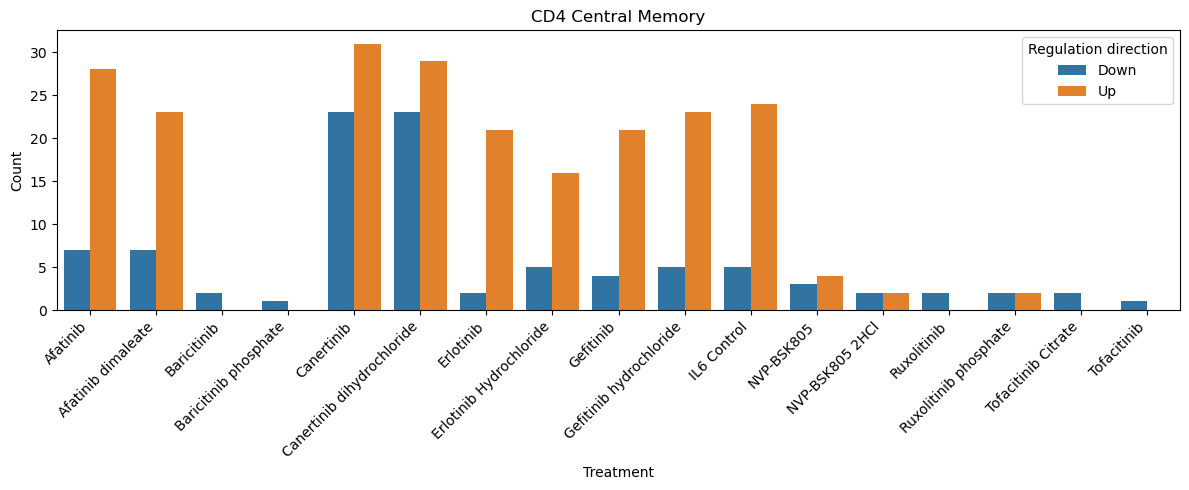

CD8 Naive


/tmp/ipykernel_1866/3148478499.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_by_treatment = sig_diff.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')


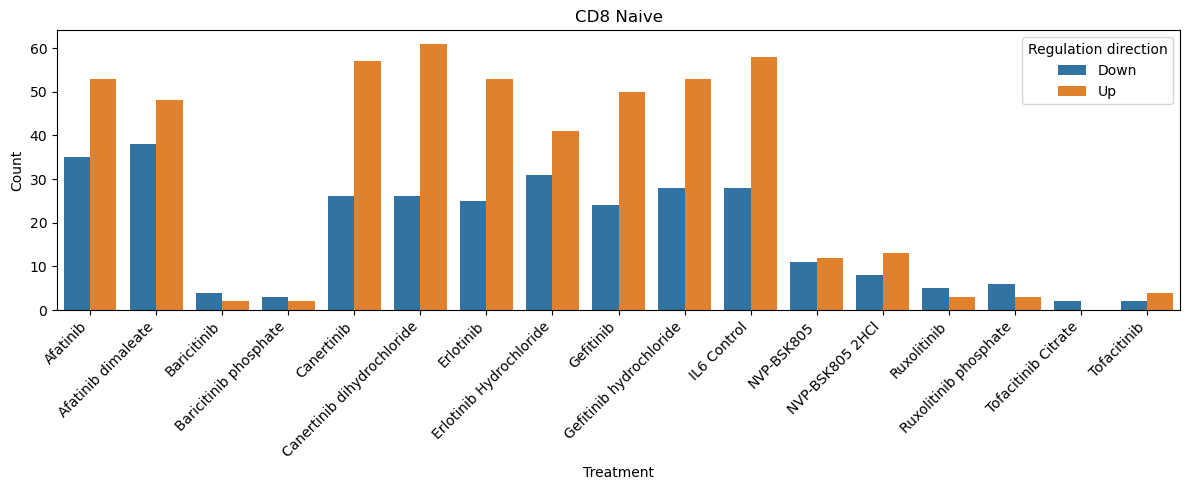

CD8 Effector Memory


/tmp/ipykernel_1866/3148478499.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_by_treatment = sig_diff.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')


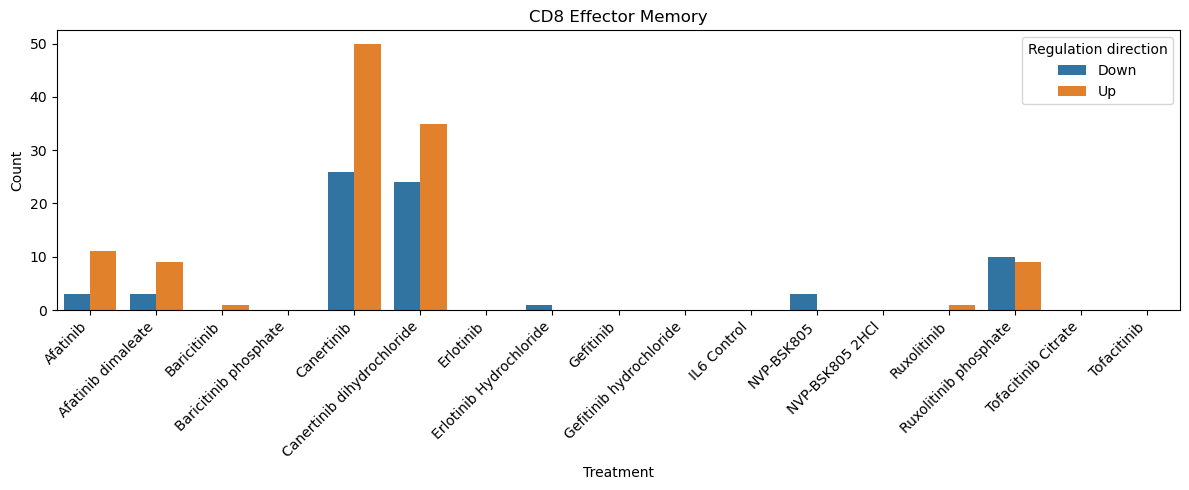

CD8 Central Memory


/tmp/ipykernel_1866/3148478499.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_by_treatment = sig_diff.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')


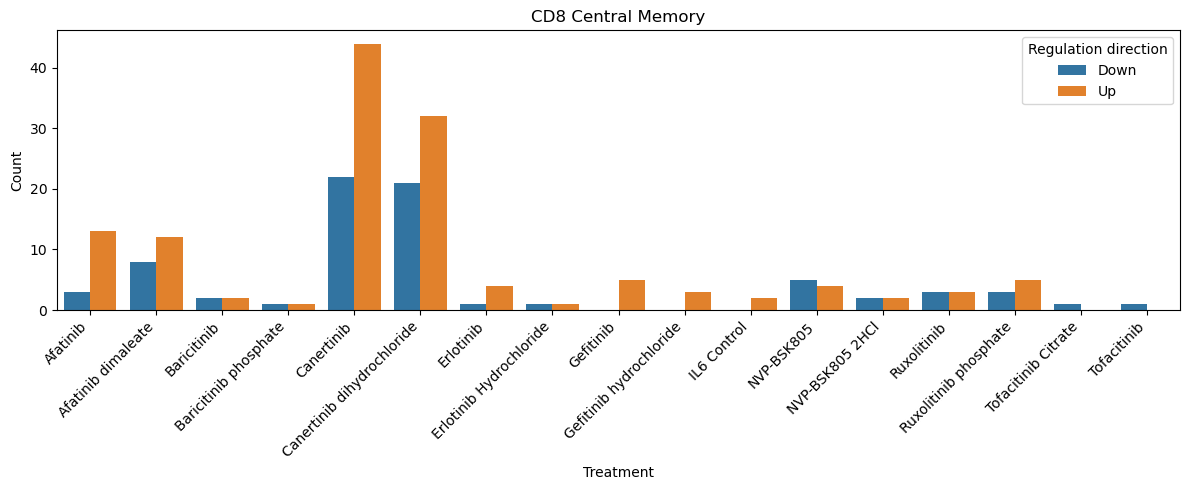

CD4 Naive


/tmp/ipykernel_1866/3148478499.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_by_treatment = sig_diff.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')


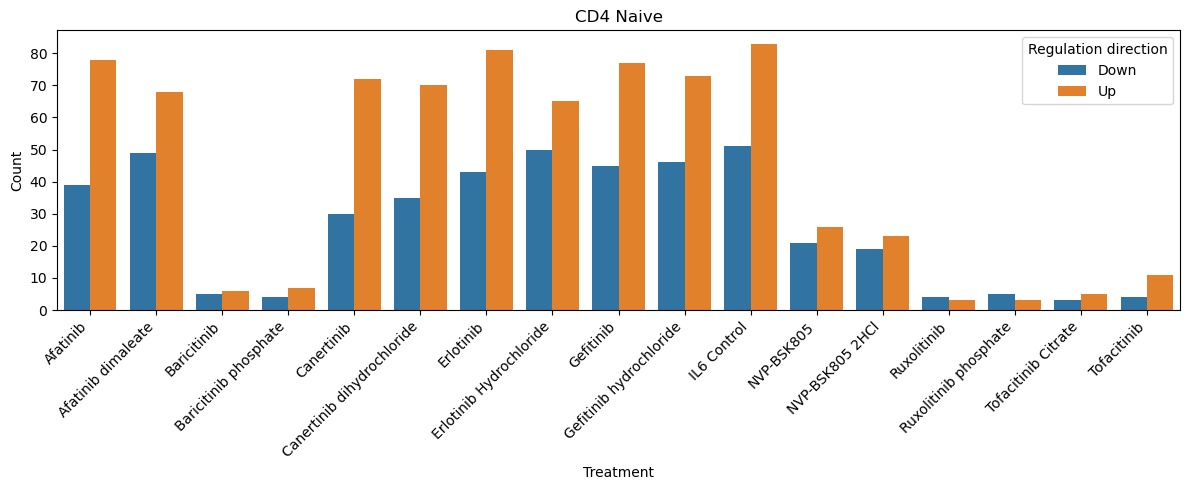

CD4 Effector Memory


/tmp/ipykernel_1866/3148478499.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_by_treatment = sig_diff.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')


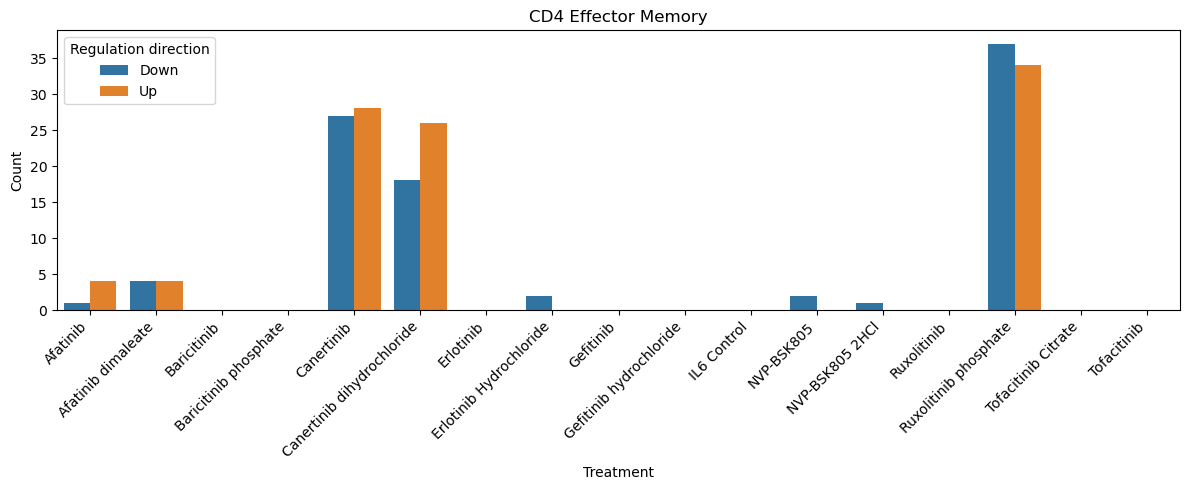

MAIT


/tmp/ipykernel_1866/3148478499.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_by_treatment = sig_diff.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')


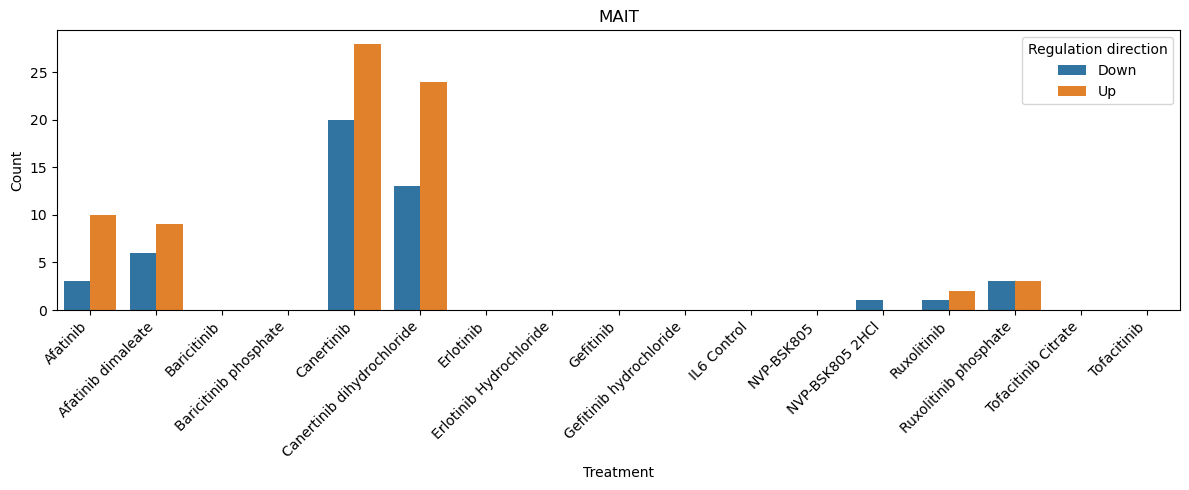

Treg


/tmp/ipykernel_1866/3148478499.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_by_treatment = sig_diff.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')


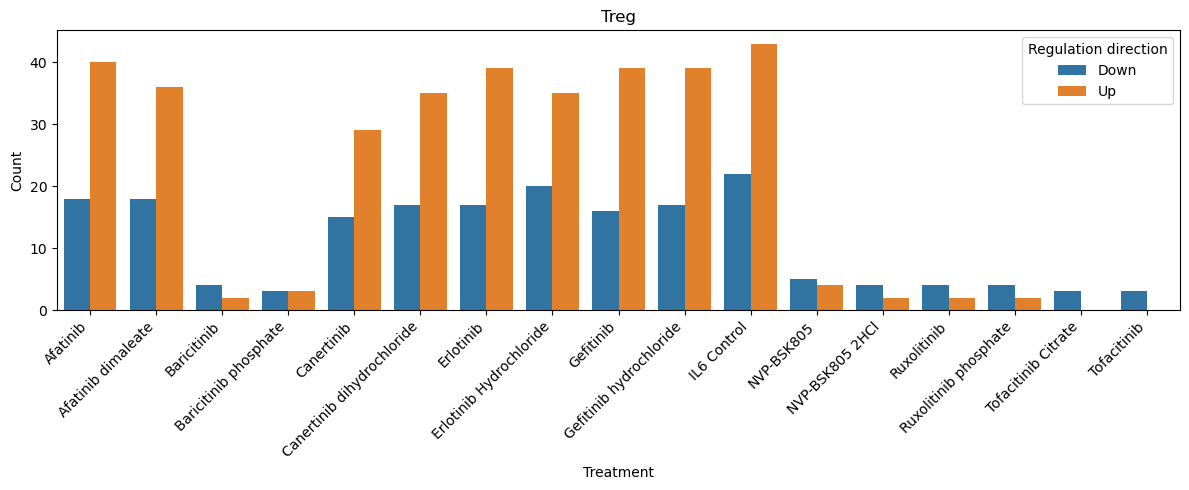

All cells
              cell_type regulation_dir  count
0    CD4 Central Memory           Down     34
1    CD4 Central Memory             Up     56
2   CD4 Effector Memory           Down     61
3   CD4 Effector Memory             Up     63
4             CD4 Naive           Down     85
5             CD4 Naive             Up    131
6    CD8 Central Memory           Down     34
7    CD8 Central Memory             Up     56
8   CD8 Effector Memory           Down     40
9   CD8 Effector Memory             Up     65
10            CD8 Naive           Down     62
11            CD8 Naive             Up    108
12                 MAIT           Down     28
13                 MAIT             Up     36
14                 Treg           Down     43
15                 Treg             Up     75
                names
regulation_dir       
Down              153
Up                235


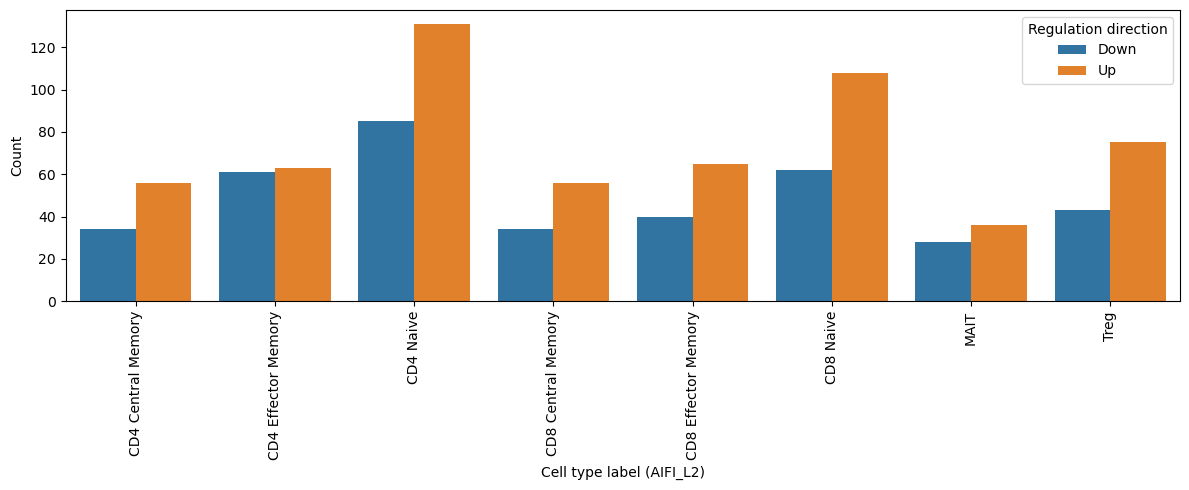

In [56]:
graph_diff_gene_counts_with_agreement(lfc_threshold = 1)

### Comparing against IL6 control significant genes

In [15]:
# todo: add distinction for gene regulation in common with IL6
# todo: adjust the threshold to 0.1 as well

# tracking all gene names that are up/down regulated in any cell
up_across_cells = set()
down_across_cells = set()

# add in grouping by drug
# plot as bar plot or heat map


def graph_diff_gene_counts(lfc_threshold):
    # initialize the dataframe
    all_cells_sig_genes = pd.DataFrame({'cell_type':[], 'names': [], 'regulation_dir': []})
    
    for cell_type, subset_cell in subsets_cells.items():

        cell_df = sc.get.rank_genes_groups_df(subset_cell, group=None)
    
        # make a column that is absolute value of logfold change
        cell_df['abs_logfoldchanges'] = cell_df['logfoldchanges'].abs()
    
        # filter for absolute value of log fold change > 1 and adjusted p values less than 0.05
        sig_diff = cell_df[(cell_df['pvals_adj'] < 0.05) & (cell_df['abs_logfoldchanges'] > lfc_threshold)].sort_values(by = 'abs_logfoldchanges', ascending = False)
        
        # add a categorical variable showing up or down regulation
        sig_diff['regulation_dir'] = np.where(sig_diff['logfoldchanges'] > 0, 'Up', 'Down')
        sig_diff['cell_type'] = cell_type
        # print(sig_diff.head())
    
        
        counts_by_treatment = sig_diff.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')
    
        # print(sig_diff.groupby('regulation')['regulation'].count())
        # concatenating these to our data frame across all cell types with a label for what the cell type is
        # also making it unique so we don't have duplicate counts across different treatment types
        all_cells_sig_genes = pd.concat([all_cells_sig_genes, sig_diff[['cell_type', 'names', 'regulation_dir']]]).drop_duplicates()
    all_cells_sig_genes.to_csv("all_cells_sig_genes.csv")
    


In [16]:
graph_diff_gene_counts(0.1)

/tmp/ipykernel_1866/483244995.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_by_treatment = sig_diff.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')
/tmp/ipykernel_1866/483244995.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_by_treatment = sig_diff.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')
/tmp/ipykernel_1866/483244995.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or obser

## Heatmaps
Let's start with the top 500 differentially expressed genes

CD4 Central Memory
Only selecting for top 500 log fold change
                            group      names     scores  logfoldchanges  \
7664                   Canertinib      HMGB2  55.764740        2.965033   
9580   Canertinib dihydrochloride      HMGB2  55.677532        2.919789   
7818                   Canertinib       IGHM   4.459087        2.811832   
9738   Canertinib dihydrochloride       IGHM   4.203644        2.714745   
7668                   Canertinib       BATF  32.710278        2.355659   
...                           ...        ...        ...             ...   
1941           Afatinib dimaleate      CCND2  16.780336        0.841803   
17231                   Gefitinib      TXNIP -20.648844       -0.841526   
7709                   Canertinib     SH2D1A  11.569473        0.839903   
15372                   Gefitinib  TNFRSF13C   9.190875        0.838876   
38                       Afatinib        HK1  12.608438        0.838874   

               pvals      pvals_adj  

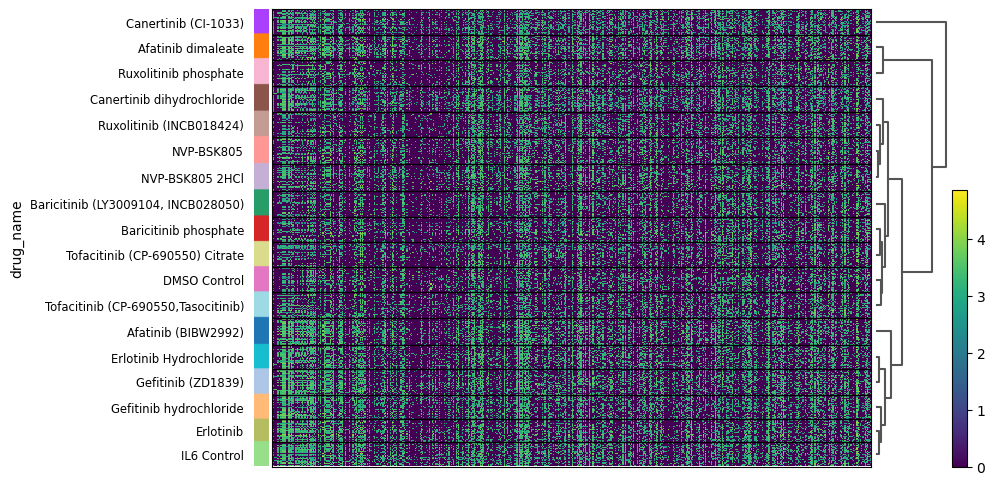

categories: Afatinib (BIBW2992), Afatinib dimaleate, Baricitinib (LY3009104, INCB028050), etc.
var_group_labels: Afatinib, Afatinib dimaleate, Baricitinib, etc.


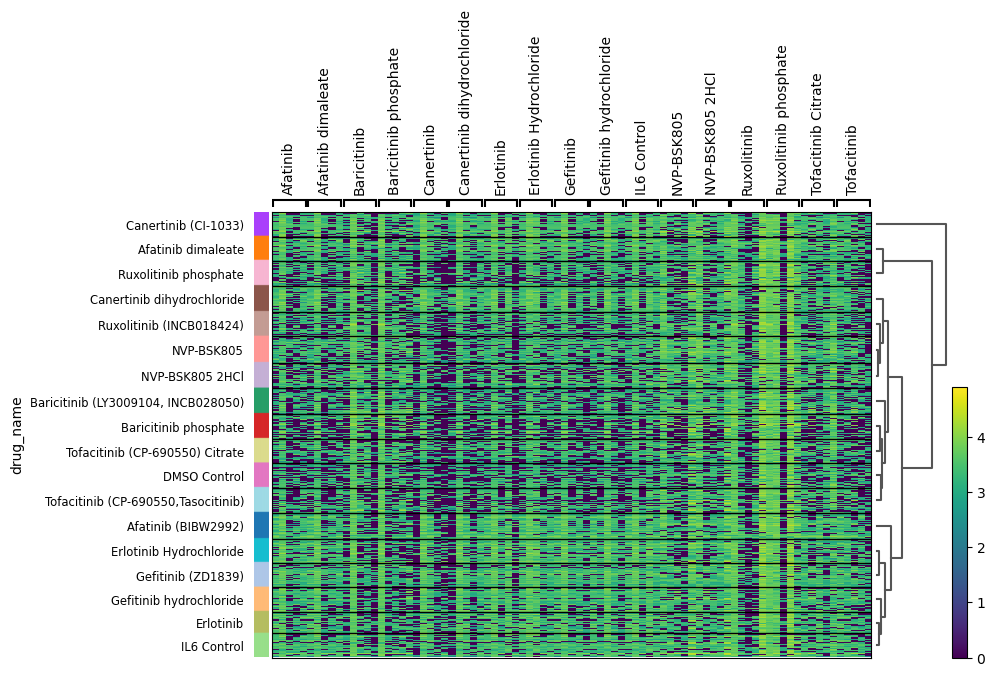

CD8 Naive
Only selecting for top 500 log fold change
                            group     names     scores  logfoldchanges  \
1919           Afatinib dimaleate      BATF  42.452785        4.830195   
1                        Afatinib      BATF  42.078945        4.809808   
7664                   Canertinib     HMGB2  60.987823        4.656802   
9586   Canertinib dihydrochloride      BATF  39.566795        4.596536   
15333                   Gefitinib      BATF  38.806232        4.562941   
...                           ...       ...        ...             ...   
13425     Erlotinib Hydrochloride      TWF2  24.894566        1.249283   
11526                   Erlotinib     NOLC1  14.827782        1.245634   
13391                   Erlotinib      JAML -26.683474       -1.244795   
21100                  NVP-BSK805     IL2RB  15.737700        1.244577   
11525                   Erlotinib  EBNA1BP2  15.258098        1.244097   

               pvals      pvals_adj  abs_logfoldchanges  


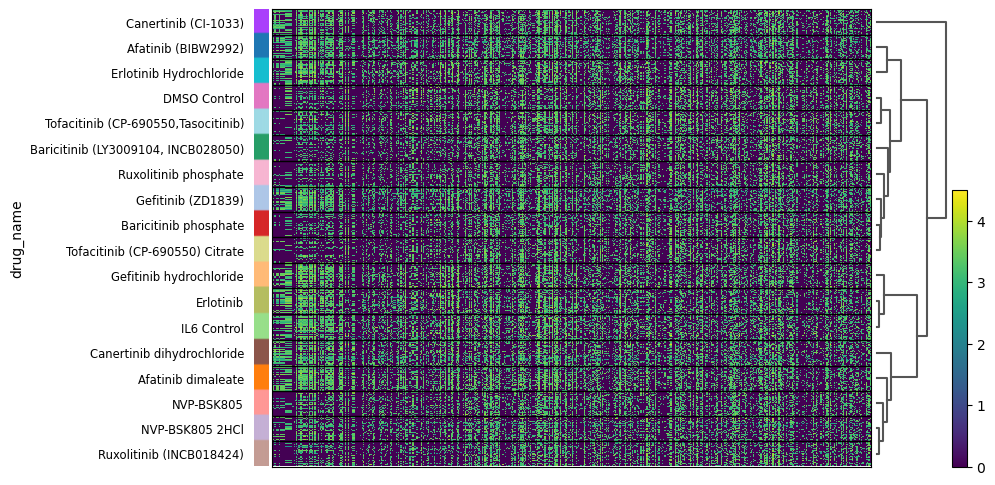

categories: Afatinib (BIBW2992), Afatinib dimaleate, Baricitinib (LY3009104, INCB028050), etc.
var_group_labels: Afatinib, Afatinib dimaleate, Baricitinib, etc.


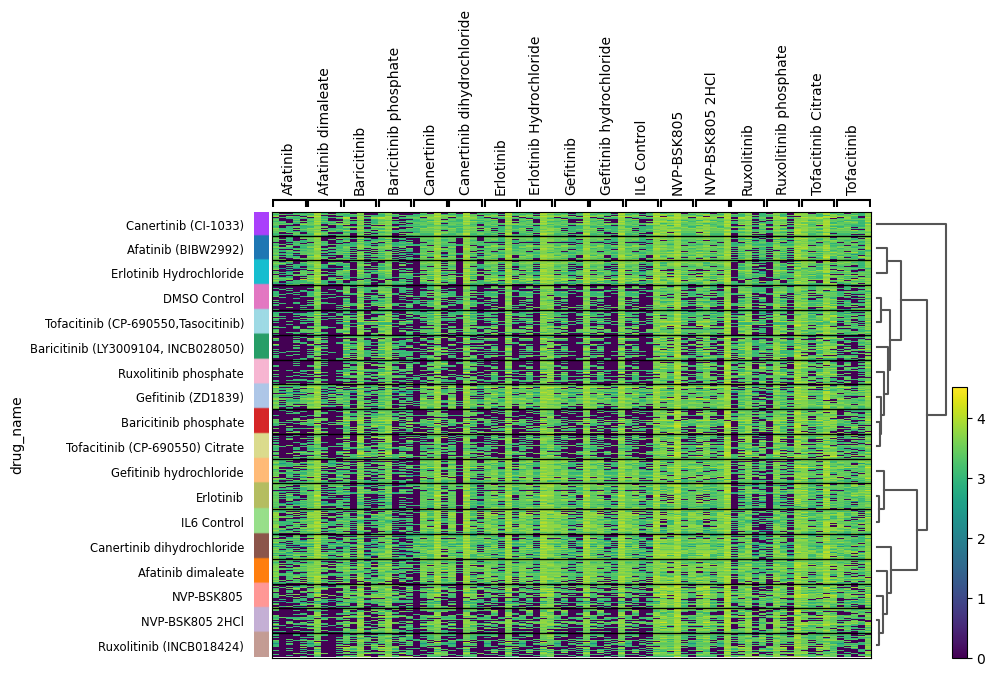

CD8 Effector Memory
Only selecting for top 500 log fold change
                            group    names     scores  logfoldchanges  \
7734                   Canertinib     IGHM   5.782417        4.898989   
9656   Canertinib dihydrochloride     IGHM   5.255484        4.753015   
7664                   Canertinib    HMGB2  33.895832        2.888356   
9580   Canertinib dihydrochloride    HMGB2  32.443760        2.827512   
7692                   Canertinib  ADORA2A   9.880302        2.704105   
...                           ...      ...        ...             ...   
24880             NVP-BSK805 2HCl     JAML  -3.611274       -0.662411   
9737   Canertinib dihydrochloride      MX1   3.031652        0.662249   
13424     Erlotinib Hydrochloride   CX3CR1   5.543903        0.661696   
24890             NVP-BSK805 2HCl    IKBKE  -4.228438       -0.661509   
28650       Ruxolitinib phosphate    C2CD5  -3.590033       -0.661489   

               pvals      pvals_adj  abs_logfoldchanges  
77

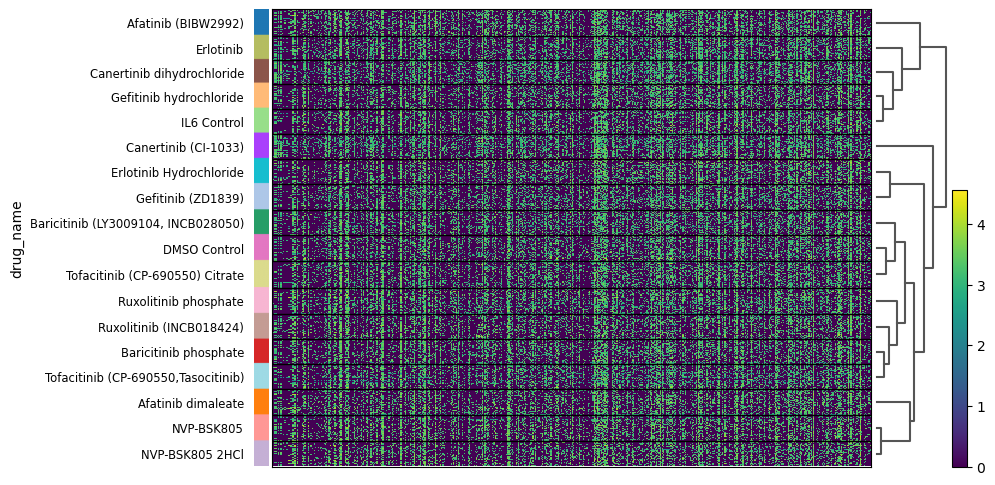

categories: Afatinib (BIBW2992), Afatinib dimaleate, Baricitinib (LY3009104, INCB028050), etc.
var_group_labels: Afatinib, Afatinib dimaleate, Baricitinib, etc.


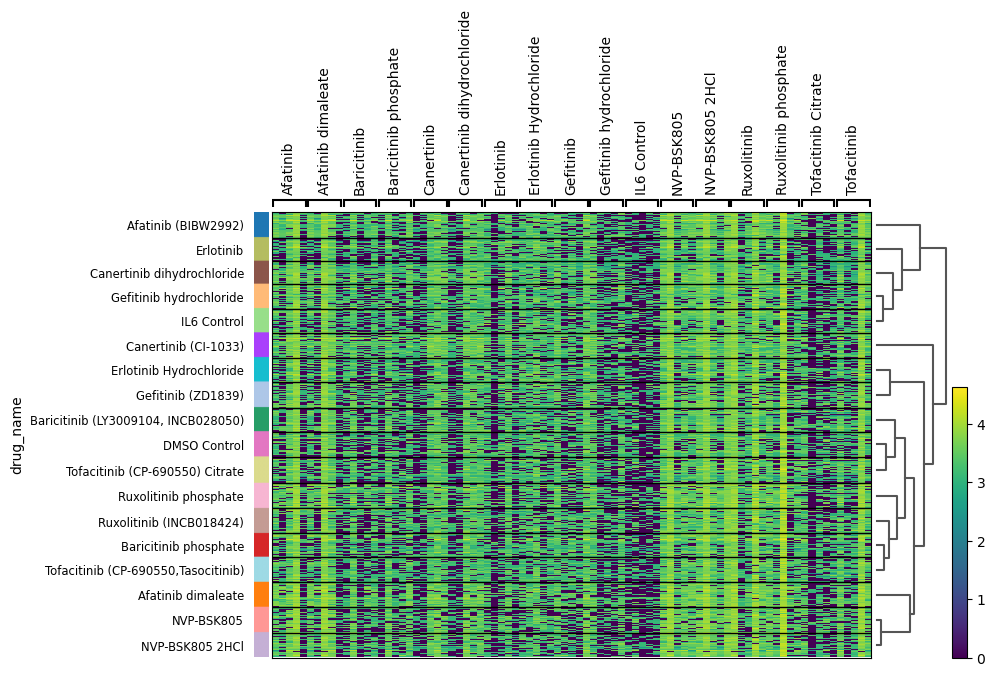

CD8 Central Memory
Only selecting for top 500 log fold change
                            group   names     scores  logfoldchanges  \
7664                   Canertinib   HMGB2  29.410284        3.601888   
9580   Canertinib dihydrochloride   HMGB2  27.794371        3.520540   
9574                   Canertinib  SEMA7A -16.360149       -3.496383   
11491  Canertinib dihydrochloride  SEMA7A -15.151285       -3.170068   
1                        Afatinib     FOS  18.983759        2.992201   
...                           ...     ...        ...             ...   
3758           Afatinib dimaleate   KLRG1  -3.477030       -0.723650   
11487  Canertinib dihydrochloride     TES -12.982887       -0.723307   
21122                  NVP-BSK805  HMGCS1   5.859991        0.721202   
11392  Canertinib dihydrochloride    CDK6  -3.924661       -0.720517   
7705                   Canertinib   SBNO2   7.193991        0.720416   

               pvals      pvals_adj  abs_logfoldchanges  
7664   4.057034

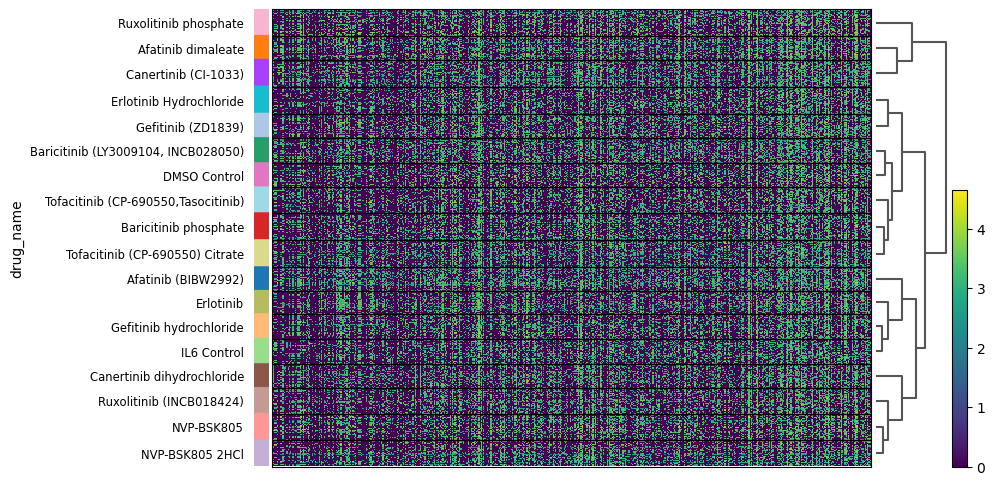

categories: Afatinib (BIBW2992), Afatinib dimaleate, Baricitinib (LY3009104, INCB028050), etc.
var_group_labels: Afatinib, Afatinib dimaleate, Baricitinib, etc.


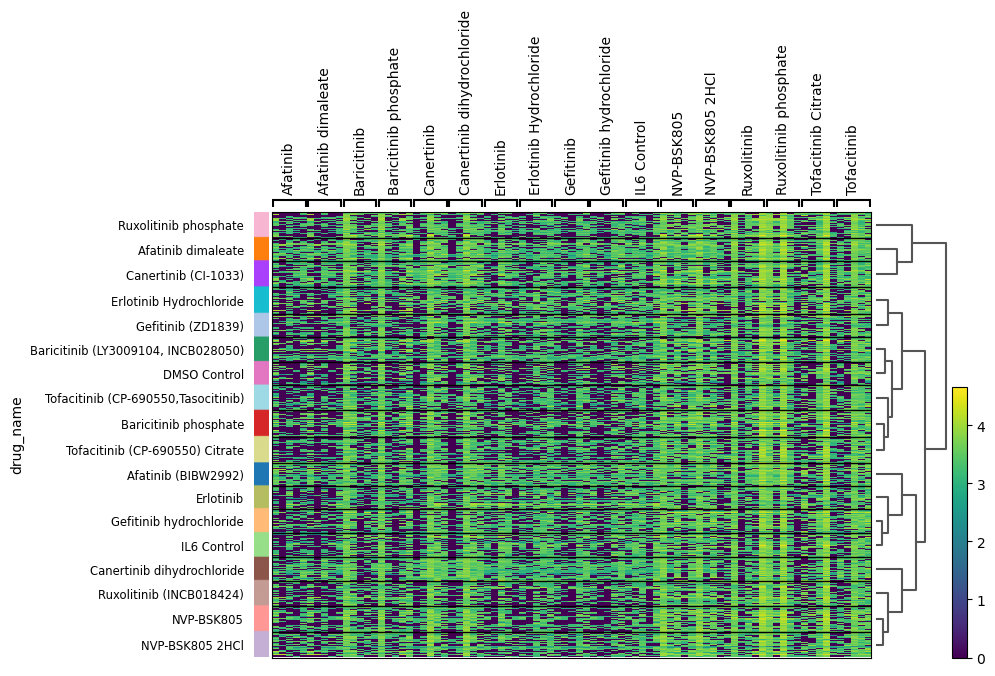

CD4 Naive
Only selecting for top 500 log fold change
                            group  names     scores  logfoldchanges  \
1                        Afatinib   BATF  61.560120        4.998376   
1918           Afatinib dimaleate   BATF  60.699821        4.891921   
19165                 IL6 Control   BATF  56.930550        4.704328   
15330                   Gefitinib   BATF  56.004692        4.688774   
17249     Gefitinib hydrochloride   BATF  56.490063        4.681890   
...                           ...    ...        ...             ...   
15416                   Gefitinib  SOCS2   9.637086        1.528955   
1949           Afatinib dimaleate  SOCS1  22.706110        1.524197   
7886                   Canertinib   JPT1   3.190105        1.524120   
9686   Canertinib dihydrochloride  FKBP4   8.885480        1.521944   
19159     Gefitinib hydrochloride    CD5 -60.891006       -1.520784   

               pvals      pvals_adj  abs_logfoldchanges  
1       0.000000e+00   0.000000e+00 

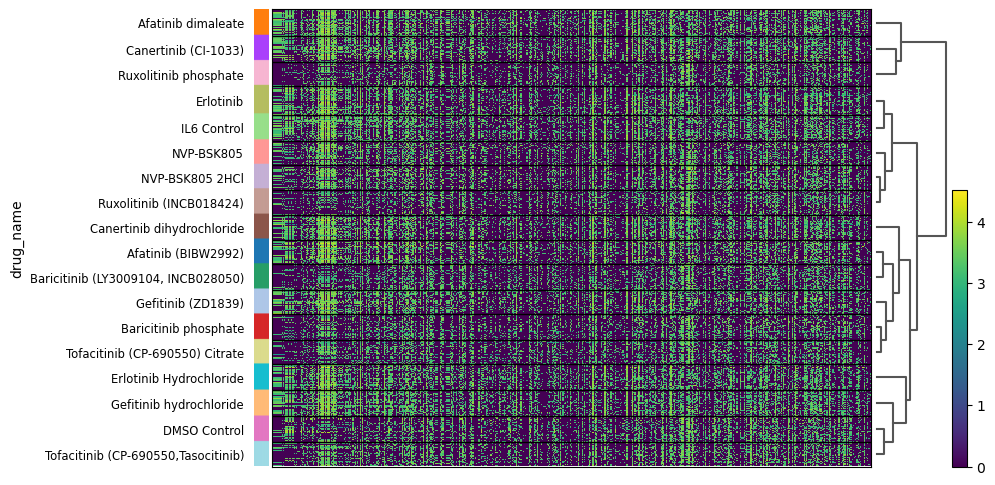

categories: Afatinib (BIBW2992), Afatinib dimaleate, Baricitinib (LY3009104, INCB028050), etc.
var_group_labels: Afatinib, Afatinib dimaleate, Baricitinib, etc.


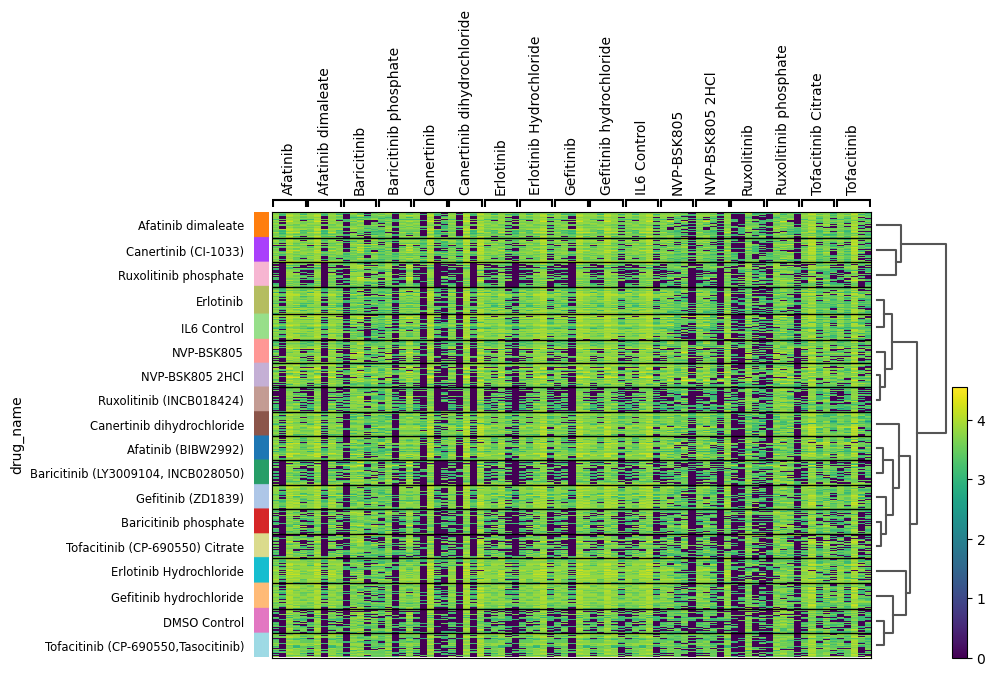

CD4 Effector Memory
Only selecting for top 500 log fold change
                            group     names     scores  logfoldchanges  \
9645   Canertinib dihydrochloride      IGHM   5.783017        5.411324   
7769                   Canertinib      IGHM   4.534716        5.037567   
28739       Ruxolitinib phosphate     TXNIP -35.431580       -2.895997   
7664                   Canertinib     HMGB2  39.195019        2.880967   
9580   Canertinib dihydrochloride     HMGB2  37.178181        2.774132   
...                           ...       ...        ...             ...   
27046       Ruxolitinib phosphate      IL4R   3.624450        0.683060   
3840                  Baricitinib     HMGB2   6.891050        0.682522   
9634   Canertinib dihydrochloride   ANKRD10   6.469582        0.682514   
11474  Canertinib dihydrochloride     RUNX1 -15.868443       -0.682438   
9633   Canertinib dihydrochloride  TNFRSF1B   6.489430        0.682256   

               pvals      pvals_adj  abs_logfold

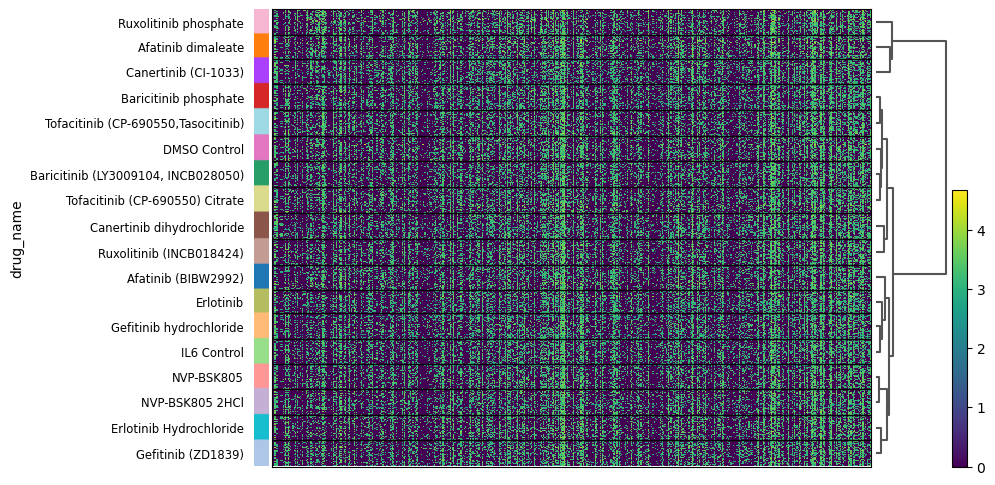

categories: Afatinib (BIBW2992), Afatinib dimaleate, Baricitinib (LY3009104, INCB028050), etc.
var_group_labels: Afatinib, Afatinib dimaleate, Baricitinib, etc.


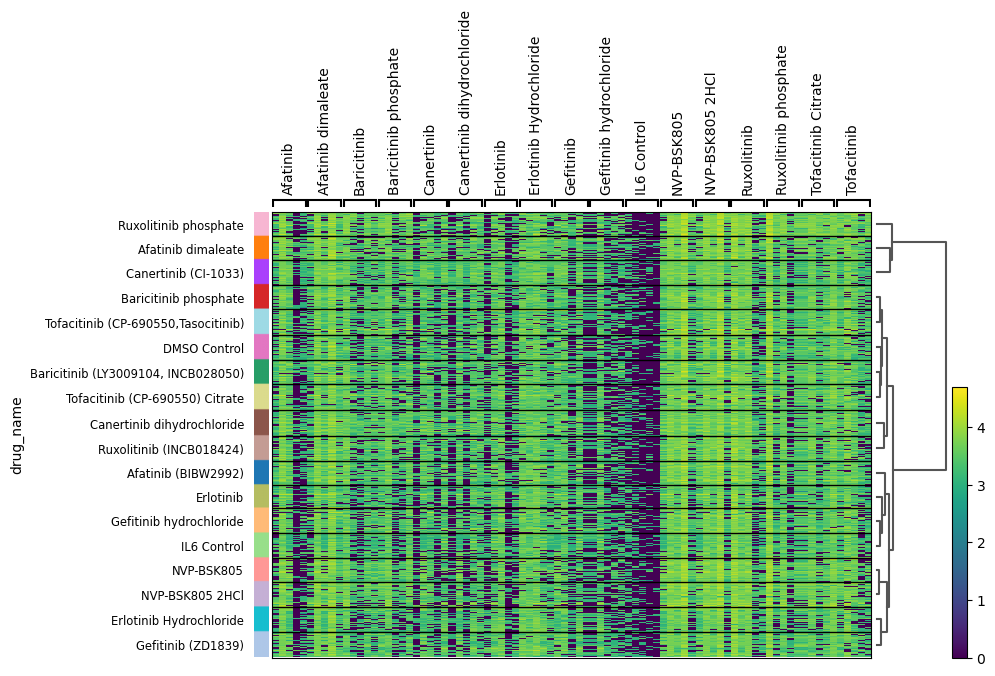

MAIT
Only selecting for top 500 log fold change
                            group   names     scores  logfoldchanges  \
11437  Canertinib dihydrochloride   LAMA3  -3.572174       -2.807184   
7665                   Canertinib   HMGB2  11.475610        2.735796   
9582   Canertinib dihydrochloride   HMGB2  10.837173        2.606860   
11488  Canertinib dihydrochloride  SEMA7A  -7.962275       -2.600801   
9566                   Canertinib  SEMA7A  -7.856130       -2.553416   
...                           ...     ...        ...             ...   
21076                  NVP-BSK805  SQSTM1   7.276722        0.258313   
11426  Canertinib dihydrochloride  MAP4K4  -3.160510       -0.256738   
11428  Canertinib dihydrochloride  CREBBP  -3.186162       -0.255031   
24926                 Ruxolitinib   EWSR1   3.598477        0.254968   
17238                   Gefitinib   FOXP1  -4.366126       -0.254448   

              pvals     pvals_adj  abs_logfoldchanges  
11437  3.540306e-04  6.339464e-

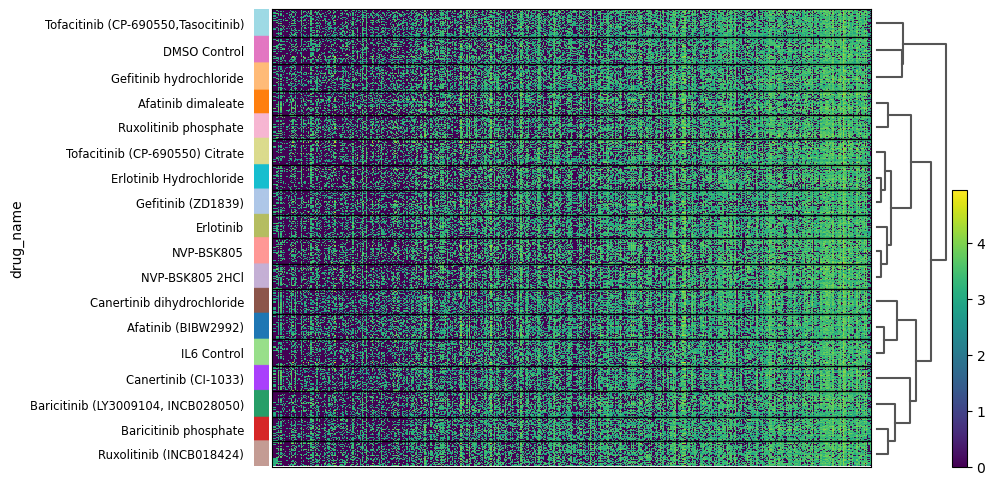

categories: Afatinib (BIBW2992), Afatinib dimaleate, Baricitinib (LY3009104, INCB028050), etc.
var_group_labels: Afatinib, Afatinib dimaleate, Baricitinib, etc.


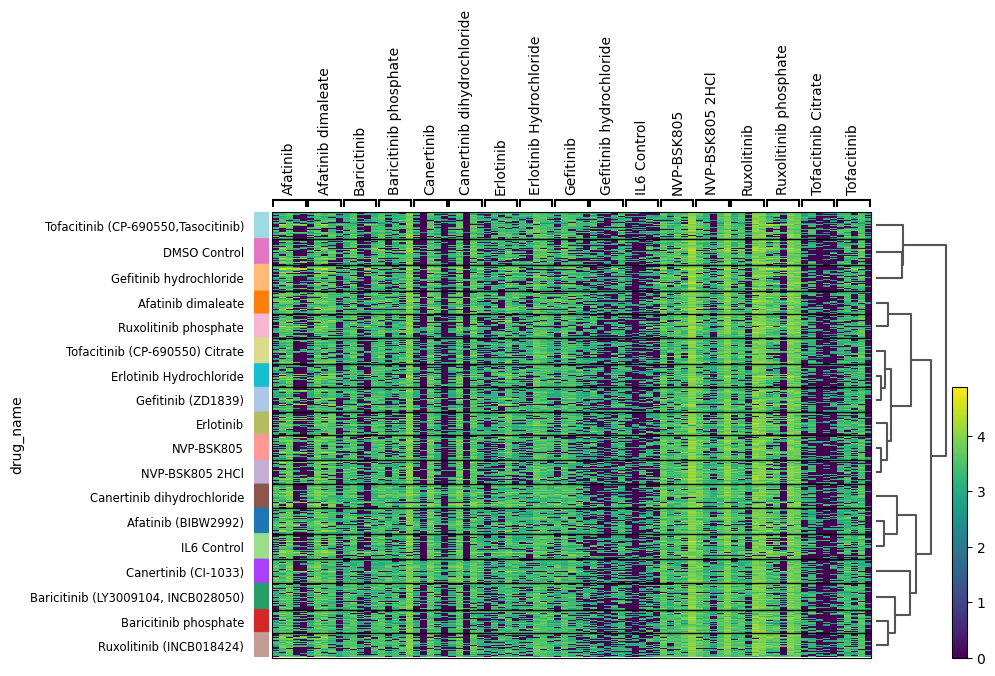

Treg
Only selecting for top 500 log fold change
                            group    names     scores  logfoldchanges  \
11452  Canertinib dihydrochloride    SMAD7  -6.775254       -3.518933   
9541                   Canertinib    SMAD7  -6.729897       -3.515301   
7664                   Canertinib    HMGB2  26.781143        3.280865   
7663        Baricitinib phosphate    STAT1 -18.984890       -3.197313   
9580   Canertinib dihydrochloride    HMGB2  25.815134        3.182686   
...                           ...      ...        ...             ...   
13398                   Erlotinib    TXNIP -12.903778       -1.041255   
11533                   Erlotinib  TP53BP2   6.586923        1.041110   
19158     Gefitinib hydrochloride      CD5 -16.936201       -1.040953   
17251     Gefitinib hydrochloride     JUNB  16.970514        1.039219   
28710       Ruxolitinib phosphate     AIM2  -3.330083       -1.038999   

               pvals      pvals_adj  abs_logfoldchanges  
11452   1.241880e

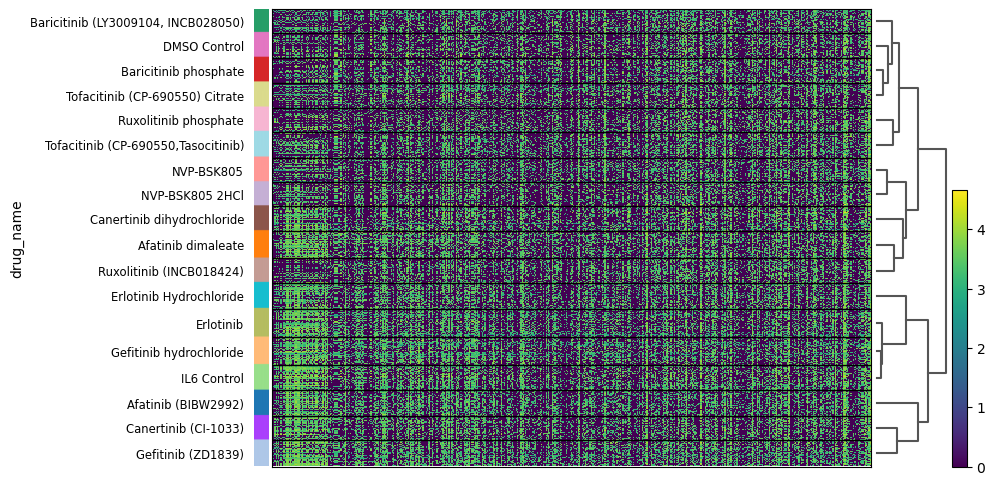

categories: Afatinib (BIBW2992), Afatinib dimaleate, Baricitinib (LY3009104, INCB028050), etc.
var_group_labels: Afatinib, Afatinib dimaleate, Baricitinib, etc.


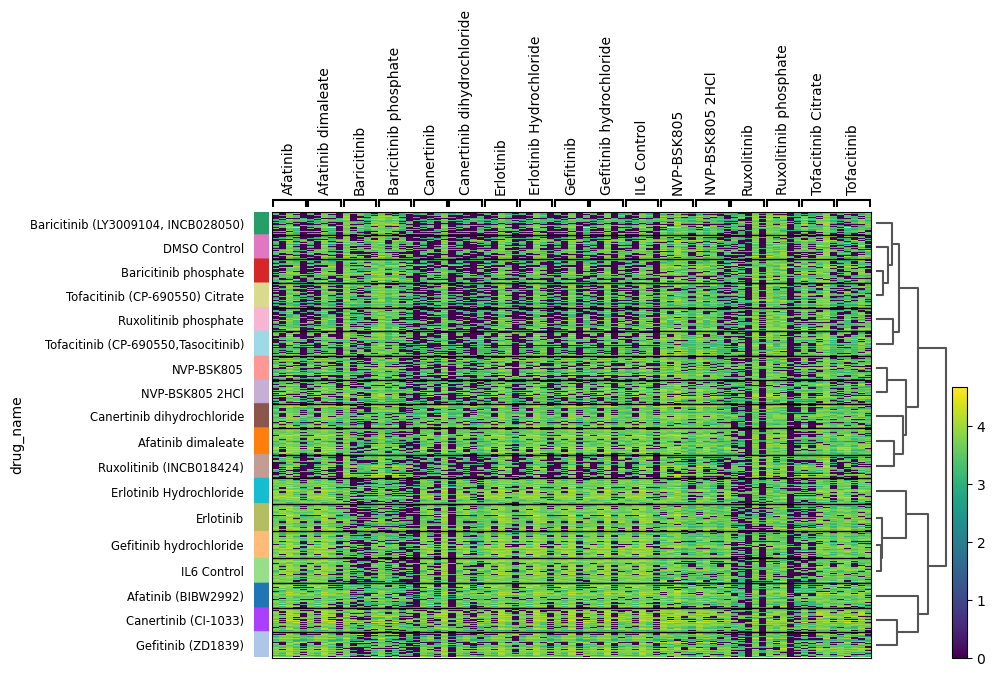

558


In [17]:
# filtering for p values less than 0.05 then sorting by log fold change

# adding this in to do a comprehensive heatmap across cell types
top_across_cells = set()

for cell_type, subset_cell in subsets_cells.items():
    print("================================")
    print(cell_type)
    print("Only selecting for top 500 log fold change")
    print("================================")
    # print(subset_cell.uns['rank_genes_groups'].keys())
    # subset_cell.uns['rank_genes_groups']
    # sc.pl.heatmap(subset_cell)
    cell_df = sc.get.rank_genes_groups_df(subset_cell, group=None)
    cell_df['abs_logfoldchanges'] = cell_df['logfoldchanges'].abs()
    # print(cell_df.head())
    # 0.05 should be good enough for an *adjusted* p value
    top_500_df = cell_df[cell_df['pvals_adj'] < 0.05].sort_values(by = "abs_logfoldchanges", ascending = False).head(500)
    print(top_500_df)


    top_500_genes = list(top_500_df["names"])
    for gene_name in top_500_genes:
        top_across_cells.add(gene_name)
    # print(top_500_genes)

    sc.pl.heatmap(subset_cell, top_500_genes, groupby = "drug_name", layer = "log_transformed", dendrogram=True)
    sc.pl.rank_genes_groups_heatmap(subset_cell, groupby="drug_name", n_genes=5)

print(len(top_across_cells))

# sc.pl.rank_genes_groups_heatmap(adata, layer = "")

It looks like, by selecting the top up/down regulated 500 significant DEGs for each cell type we wind up with 558 genes across all cell types. Let's look at these in a heatmap across all the cell types.

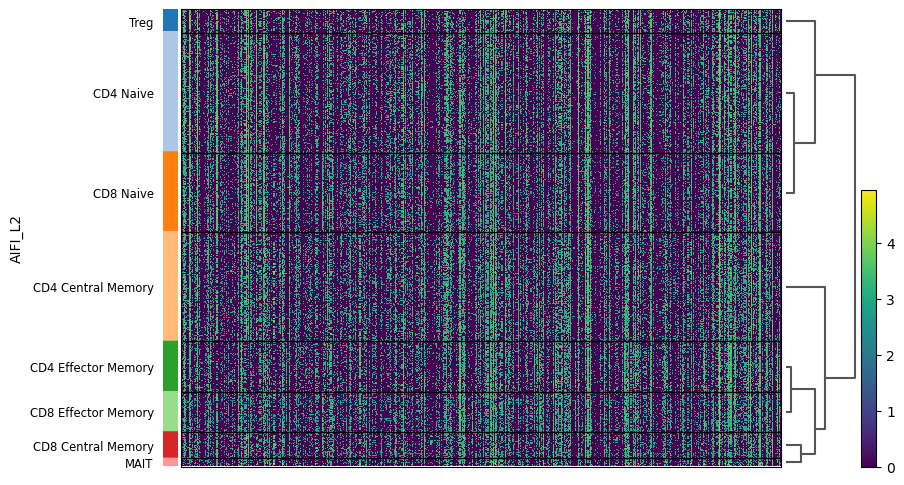

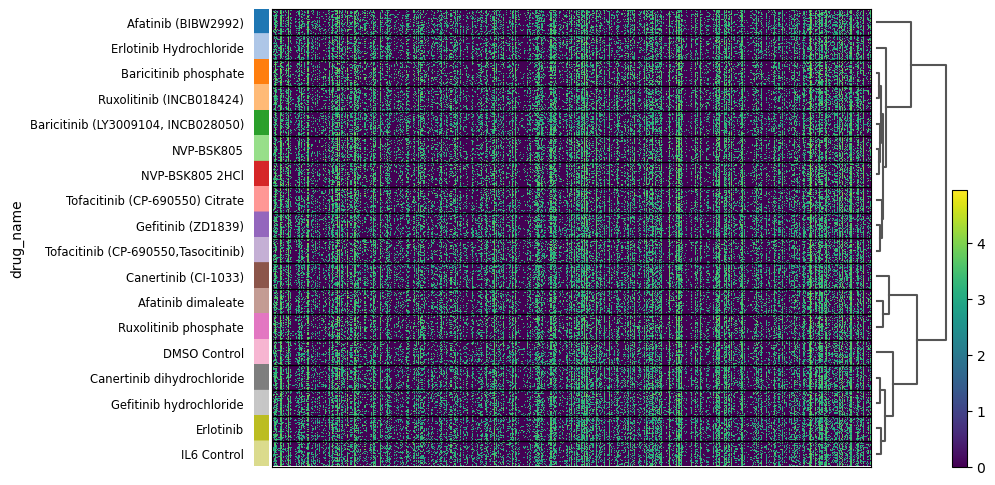

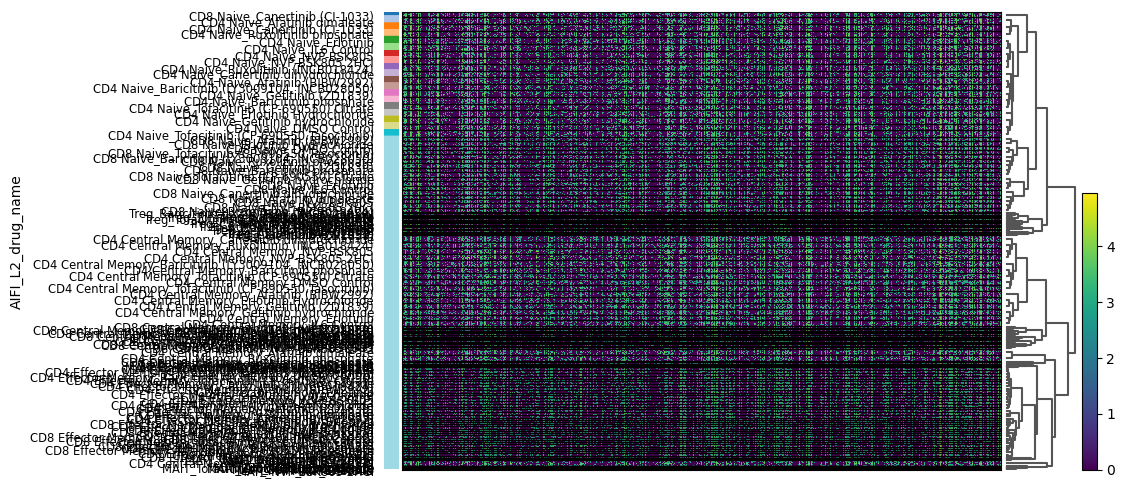

In [18]:
top_across_cells = list(top_across_cells)

sc.pl.heatmap(adata, top_across_cells, groupby = ["AIFI_L2"],  layer = "log_transformed", dendrogram=True)

sc.pl.heatmap(adata, top_across_cells, groupby = ["drug_name"],  layer = "log_transformed", dendrogram=True)

# trying to figure out 
sc.pl.heatmap(adata, top_across_cells, groupby = ["AIFI_L2", "drug_name"],  layer = "log_transformed", dendrogram=True)

CD4 Central Memory
Filtering for log fold change > 1 and then for top 500
             group  names     scores  logfoldchanges          pvals  \
19160  IL6 Control  SBNO2  60.260761        2.309811   0.000000e+00   
19165  IL6 Control   BATF  28.283314        2.107305  5.544213e-176   
19162  IL6 Control  IL2RB  38.148853        1.983307   0.000000e+00   
19253  IL6 Control   CDK1   4.549823        1.884469   5.369098e-06   
19168  IL6 Control    MYC  26.532970        1.807267  4.038277e-155   
...            ...    ...        ...             ...            ...   
20913  IL6 Control   BRAF  -4.044529       -0.106565   5.242833e-05   
20912  IL6 Control   NCK1  -4.019385       -0.105691   5.835025e-05   
19303  IL6 Control    CD2   3.039025        0.102783   2.373453e-03   
20996  IL6 Control   CD55  -7.887204       -0.100439   3.090319e-15   
21062  IL6 Control  CXCR4 -19.321711       -0.100003   3.527587e-83   

           pvals_adj  abs_logfoldchanges  
19160   0.000000e+00          

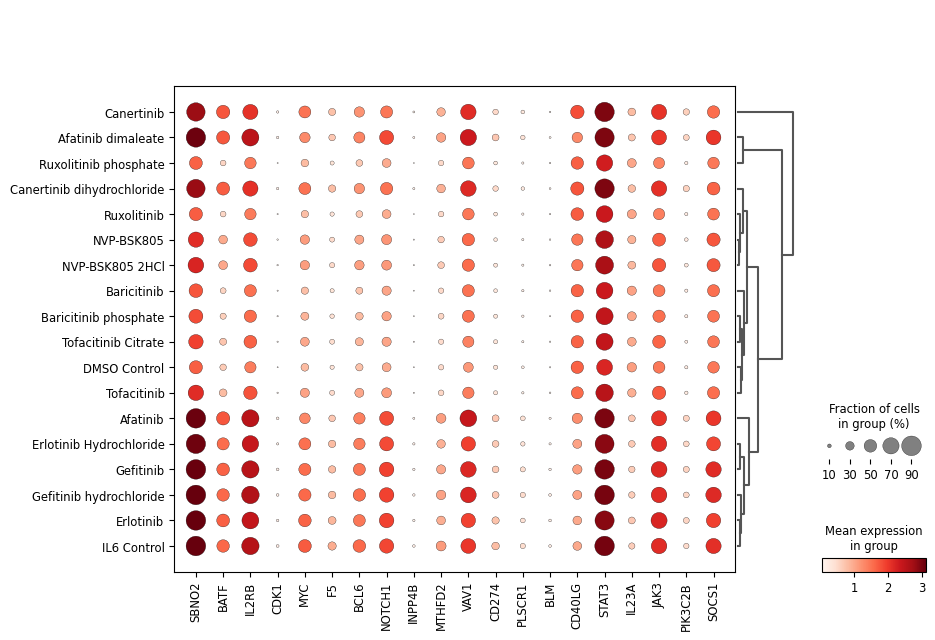

CD8 Naive
Filtering for log fold change > 1 and then for top 500
             group     names     scores  logfoldchanges         pvals  \
19165  IL6 Control      BATF  38.722214        4.535584  0.000000e+00   
19160  IL6 Control     SBNO2  66.217400        3.002756  0.000000e+00   
19162  IL6 Control    NOTCH1  43.235703        2.998714  0.000000e+00   
19163  IL6 Control     IL2RB  43.174217        2.989676  0.000000e+00   
19219  IL6 Control        F5  10.507141        2.949960  8.008488e-26   
...            ...       ...        ...             ...           ...   
20932  IL6 Control    CDC25B  -6.583142       -0.104563  4.606091e-11   
21003  IL6 Control      CD55 -12.070702       -0.103632  1.508435e-33   
20871  IL6 Control    ATP2C1  -4.440629       -0.102465  8.969633e-06   
20824  IL6 Control    CYFIP2  -3.488586        0.100475  4.855817e-04   
20829  IL6 Control  SLC25A46  -3.609637       -0.100171  3.066257e-04   

          pvals_adj  abs_logfoldchanges  
19165  0.000000e

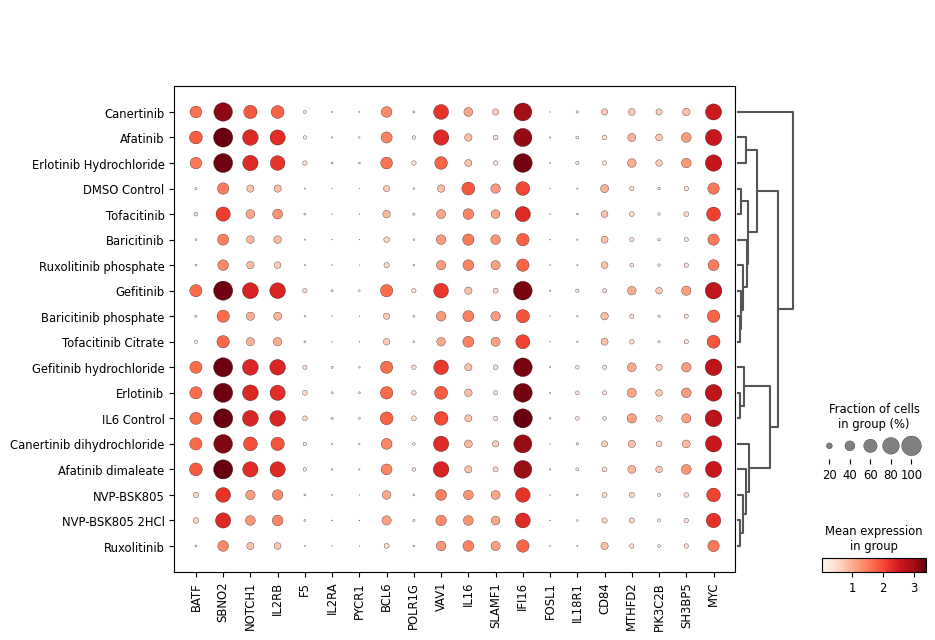

CD8 Effector Memory
Filtering for log fold change > 1 and then for top 500
             group names    scores  logfoldchanges    pvals  pvals_adj  \
21074  IL6 Control  CD52 -4.421103       -0.137386  0.00001   0.007359   

       abs_logfoldchanges  
21074            0.137386  
['CD52']


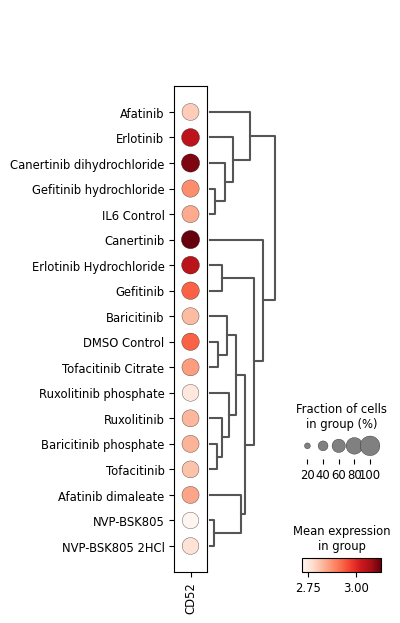

CD8 Central Memory
Filtering for log fold change > 1 and then for top 500
             group    names     scores  logfoldchanges         pvals  \
19160  IL6 Control    SBNO2  15.921474        1.465850  4.496608e-57   
19185  IL6 Control     BATF   3.592334        1.012025  3.277298e-04   
19163  IL6 Control     JAK3   8.085828        0.984734  6.174357e-16   
19167  IL6 Control     VAV1   6.864940        0.957364  6.651922e-12   
19168  IL6 Control   NOTCH1   5.726190        0.849606  1.027115e-08   
...            ...      ...        ...             ...           ...   
21045  IL6 Control      CD6  -4.057532       -0.143903  4.959404e-05   
21034  IL6 Control    ISG20  -3.505929       -0.138435  4.550173e-04   
21060  IL6 Control    NR3C1  -4.617055       -0.115823  3.892242e-06   
21032  IL6 Control    EP300  -3.357470       -0.115719  7.865924e-04   
21072  IL6 Control  TNFAIP3  -5.988725       -0.104272  2.114930e-09   

          pvals_adj  abs_logfoldchanges  
19160  8.615501e-54

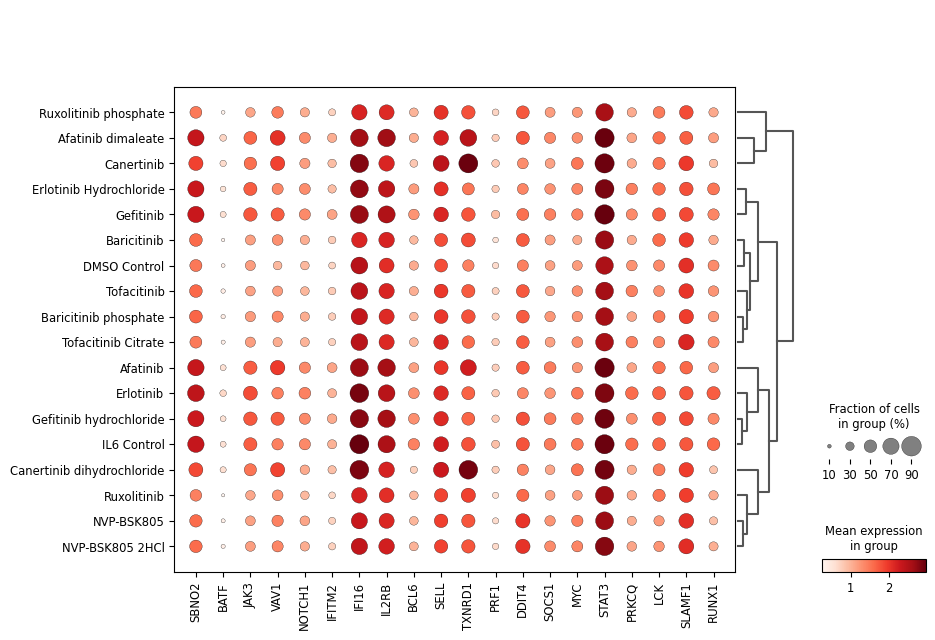

CD4 Naive
Filtering for log fold change > 1 and then for top 500
             group    names     scores  logfoldchanges          pvals  \
19165  IL6 Control     BATF  56.930550        4.704328   0.000000e+00   
19175  IL6 Control    IL2RB  36.160671        2.994796  2.528835e-286   
21069  IL6 Control     IL16 -48.060371       -2.866199   0.000000e+00   
19186  IL6 Control   MTHFD2  27.705912        2.861655  5.926070e-169   
19179  IL6 Control       F5  31.535601        2.856346  2.825240e-218   
...            ...      ...        ...             ...            ...   
20783  IL6 Control  DENND2D  -2.976457       -0.122029   2.915996e-03   
20854  IL6 Control    CIRBP  -4.878911        0.114208   1.066732e-06   
19335  IL6 Control     LEF1   5.327348        0.113263   9.965729e-08   
20974  IL6 Control   SPTAN1 -13.163984       -0.108801   1.414275e-39   
21033  IL6 Control     TCF7 -25.688656       -0.102956  1.565157e-145   

           pvals_adj  abs_logfoldchanges  
19165   0.00000

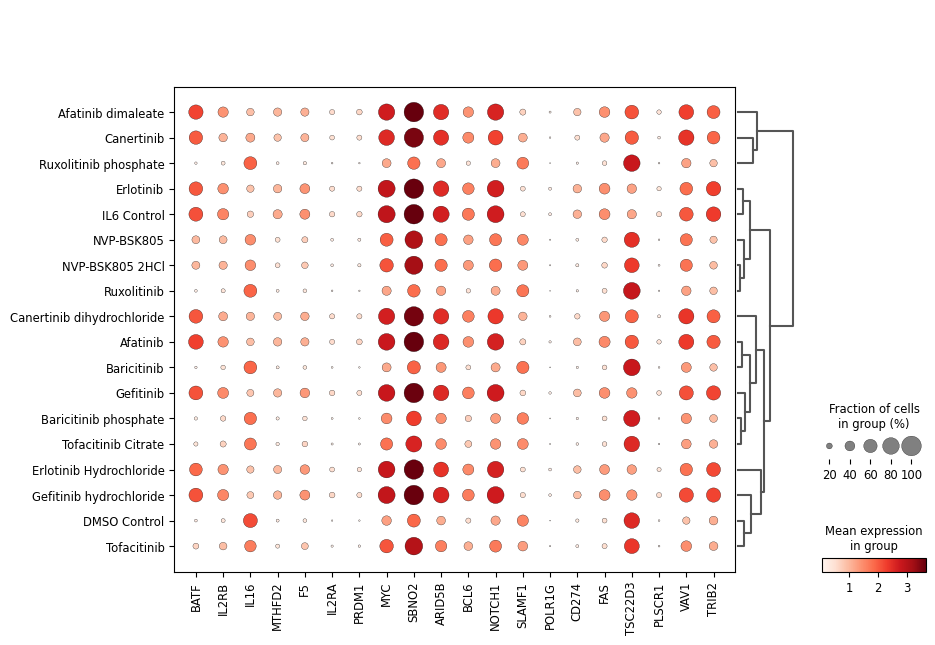

CD4 Effector Memory
Filtering for log fold change > 1 and then for top 500
             group     names    scores  logfoldchanges         pvals  \
21060  IL6 Control   TSC22D3 -4.340798       -0.152516  1.419663e-05   
21074  IL6 Control  PAFAH1B1 -5.590432       -0.122739  2.265057e-08   
21037  IL6 Control     CHIC2 -3.435174       -0.113758  5.921747e-04   
21056  IL6 Control      BMI1 -4.181732       -0.107896  2.892973e-05   
21039  IL6 Control      CCL4 -3.539397       -0.103170  4.010422e-04   
21040  IL6 Control     DRAP1 -3.541404       -0.103067  3.980043e-04   

       pvals_adj  abs_logfoldchanges  
21060   0.001663            0.152516  
21074   0.000022            0.122739  
21037   0.029092            0.113758  
21056   0.002771            0.107896  
21039   0.020767            0.103170  
21040   0.020767            0.103067  
['TSC22D3' 'PAFAH1B1' 'CHIC2' 'BMI1' 'CCL4' 'DRAP1']


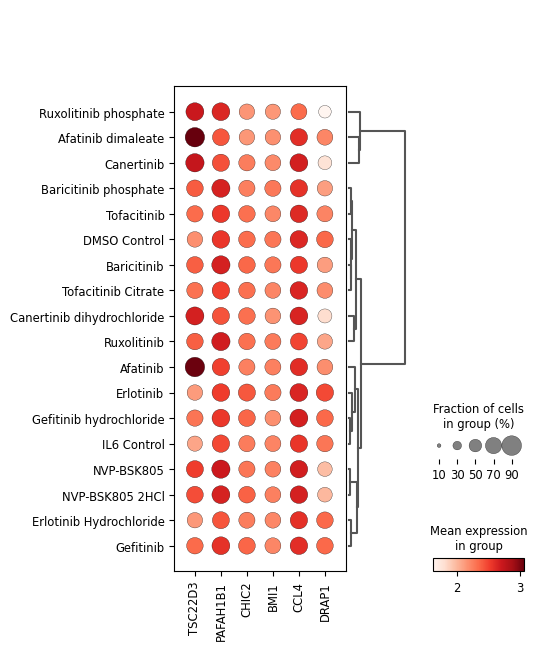

MAIT
Filtering for log fold change > 1 and then for top 500
Empty DataFrame
Columns: [group, names, scores, logfoldchanges, pvals, pvals_adj, abs_logfoldchanges]
Index: []
[]
Treg
Filtering for log fold change > 1 and then for top 500
             group   names     scores  logfoldchanges          pvals  \
19160  IL6 Control   SBNO2  34.536629        2.885511  2.263102e-261   
19164  IL6 Control    BATF  19.946379        2.844364   1.611437e-88   
19161  IL6 Control   IL2RA  26.933683        2.784782  8.858941e-160   
19165  IL6 Control     MYC  18.972635        2.565231   2.871492e-80   
19189  IL6 Control   SOCS2   9.116254        2.223146   7.776576e-20   
...            ...     ...        ...             ...            ...   
20950  IL6 Control  TUBB4B  -2.785037       -0.137035   5.352160e-03   
21009  IL6 Control    CD74  -5.664759       -0.136614   1.472316e-08   
21004  IL6 Control  IL10RA  -5.227021       -0.130660   1.722630e-07   
20958  IL6 Control  NFKBIA  -2.992194       -

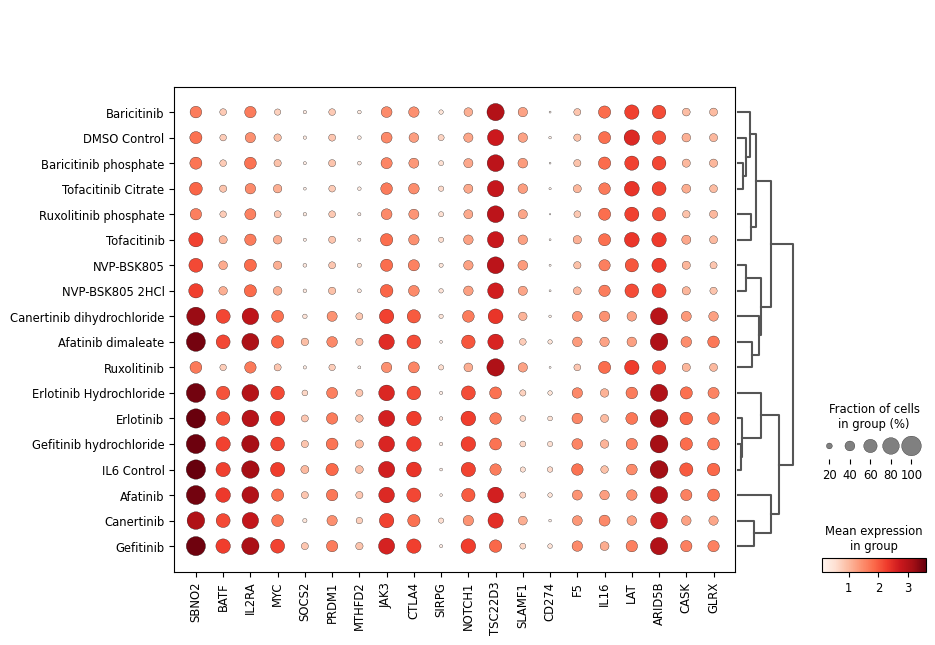

In [31]:
# trying this again but also filtering for absolute value of log fold change values greater than 1 as well
# adding this in to do a comprehensive heatmap across cell types

#todo: 

top_across_cells = set()

top_n = 20
for cell_type, subset_cell in subsets_cells.items():
    print("================================")
    print(cell_type)
    print("Filtering for log fold change > 1 and then for top 500")
    print("================================")
    # print(subset_cell.uns['rank_genes_groups'].keys())
    # subset_cell.uns['rank_genes_groups']
    # sc.pl.heatmap(subset_cell)
    cell_df = sc.get.rank_genes_groups_df(subset_cell, group=None)
    cell_df['abs_logfoldchanges'] = cell_df['logfoldchanges'].abs()

    # print(cell_df)
    # print(cell_df.head())
    # 0.05 should be good enough for an *adjusted* p value
    # can leave logfold change filter to 1 for just top results
    top_genes_df = cell_df[(cell_df['pvals_adj'] < 0.05) & (cell_df['abs_logfoldchanges'] > .1) & (cell_df["group"] == "IL6 Control")]
    top_genes_df = top_genes_df.sort_values(by = "abs_logfoldchanges", ascending = False)
    print(top_genes_df)
    
    top_genes = top_genes_df['names'].unique()[:top_n]
    print(top_genes)


    for gene_name in top_genes:
        top_across_cells.add(gene_name)
    # print(top_500_genes)

    # doing this because some cell types don't have any significantly up/down regulated genes for IL6
    if top_genes.size > 0:
        sc.pl.dotplot(subset_cell, top_genes, groupby = "clean_drug_name", layer = "log_transformed", dendrogram=True, 
                      save=f'dot_plot_{cell_type}_top_{top_n}.svg'.replace(' ', '_'))
    else:
        print("No significant top genes found.")
    # sc.pl.rank_genes_groups_heatmap(subset_cell, groupby="drug_name", n_genes=5)

# print(len(top_across_cells))

# sc.pl.rank_genes_groups_heatmap(adata, layer = "")

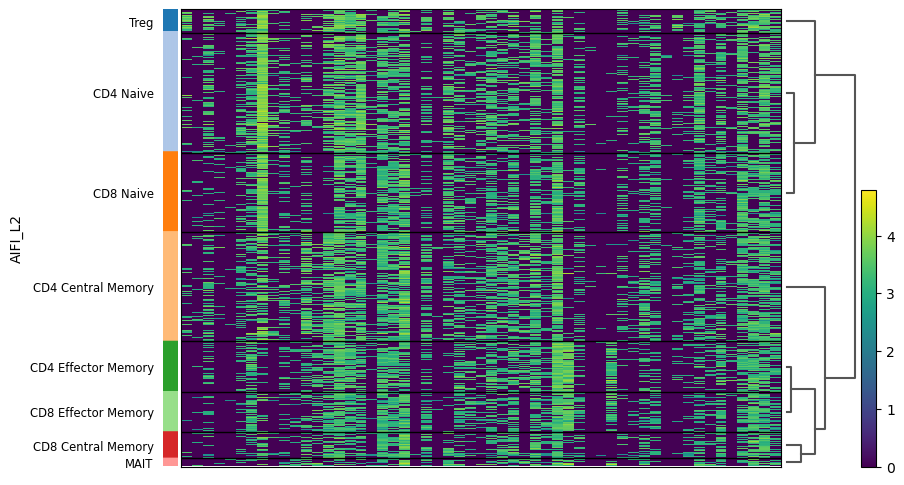

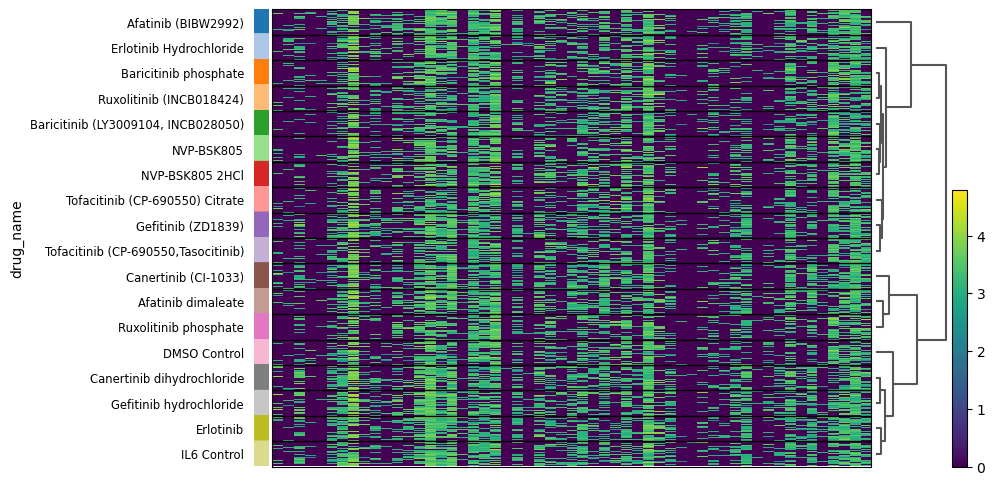

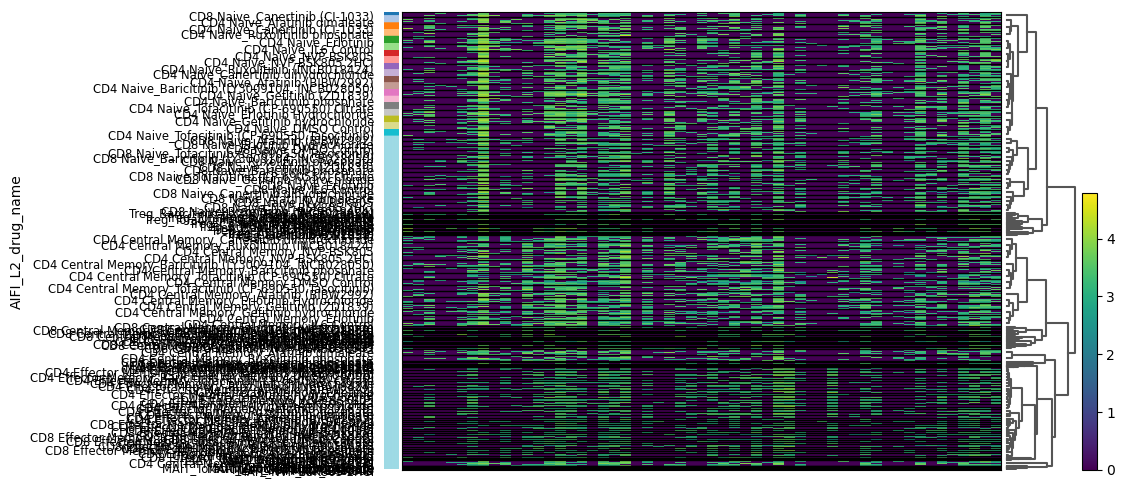

In [32]:
top_across_cells = list(top_across_cells)

sc.pl.heatmap(adata, top_across_cells, groupby = ["AIFI_L2"],  layer = "log_transformed", dendrogram=True)

sc.pl.heatmap(adata, top_across_cells, groupby = ["drug_name"],  layer = "log_transformed", dendrogram=True)


plt.rcParams['figure.figsize'] = (10, 15)
# trying to figure out 
sc.pl.heatmap(adata, top_across_cells, groupby = ["AIFI_L2", "drug_name"], layer = "log_transformed", dendrogram=True)